# Trabalho 11 - Equalização de histograma

**Disciplina:** Processamento Digital de Imagens  
**Professor:** André Alessandro Stein  
**Aluno:** Igor Kammer Grahl  
**Instituição:** IFC - Campus Rio do Sul

## Enunciado

Gerar a equalização por histograma das quatro imagens fornecidas:

| Item | Arquivo de entrada |
|:---:|---|
| (a) | `Fig0316(1)(top_left).tif` |
| (b) | `Fig0316(2)(2nd_from_top).tif` |
| (c) | `Fig0316(3)(third_from_top).tif` |
| (d) | `Fig0316(4)(bottom_left).tif` |

As imagens estão na pasta `entrada/`. Os resultados são gravados em `saida/`,
seguindo a organização dos trabalhos anteriores. O código calcula a equalização
diretamente com NumPy; Pillow é usado para ler e gravar os arquivos TIFF e PNG.

**Execução:** selecionar o kernel Python e executar todas as células em ordem.
Dependências: NumPy, Matplotlib e Pillow, além do ambiente Jupyter.
O notebook já contém os resultados de uma execução completa.

## 1. Método do material

Para uma imagem com $M \times N$ pixels e $L$ níveis possíveis, o histograma
$h(k)=n_k$ conta os pixels com intensidade $k$. A probabilidade de cada nível é:

$$p_r(r_k)=\frac{n_k}{MN}.$$

A distribuição acumulada soma as probabilidades até o nível $k$:

$$CDF(k)=\sum_{j=0}^{k}p_r(r_j).$$

A transformação apresentada no material é:

$$s_k=(L-1)\,CDF(k).$$

Como o resultado deve ser inteiro, cada $s_k$ é arredondado para o inteiro mais
próximo. Para valores não negativos, o código usa $\lfloor s_k+0{,}5\rfloor$;
em um empate, como 10,5, escolhe 11. Depois, cada pixel de valor $k$ é substituído
pelo valor correspondente na tabela de transformação.

Nas quatro imagens, $L=256$. O procedimento é:

1. Contar os pixels em cada um dos 256 níveis.
2. Calcular as probabilidades e a distribuição acumulada.
3. Multiplicar a acumulada por 255 e arredondar.
4. Aplicar a tabela de transformação a todos os pixels.

**Escolha da fórmula:** esta implementação usa diretamente a expressão do PDF,
sem subtrair a primeira probabilidade acumulada não nula (`CDF_min`). Assim, o
menor nível presente na saída não precisa ser 0. Essa escolha é importante ao
comparar o resultado com implementações que normalizam a CDF de outra forma.

O histograma equalizado discreto não precisa ser uniforme: todos os pixels de
um mesmo nível de entrada recebem o mesmo valor de saída. O arredondamento
também pode reunir níveis diferentes em um só.

In [1]:
%matplotlib inline

import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Markdown, display

# Permite executar a partir da pasta da atividade ou da raiz do repositório.
BASE = Path.cwd()
if not (BASE / "entrada" / "Fig0316(1)(top_left).tif").is_file():
    BASE = BASE / "TrabalhoEqualizacaoHistograma"

ENTRADA = BASE / "entrada"
SAIDA = BASE / "saida"
SAIDA.mkdir(parents=True, exist_ok=True)

ARQUIVOS = {
    "a": "Fig0316(1)(top_left).tif",
    "b": "Fig0316(2)(2nd_from_top).tif",
    "c": "Fig0316(3)(third_from_top).tif",
    "d": "Fig0316(4)(bottom_left).tif",
}

faltantes = [nome for nome in ARQUIVOS.values() if not (ENTRADA / nome).is_file()]
if faltantes:
    raise FileNotFoundError(
        "Extraia a pasta completa da atividade e mantenha as imagens em entrada/. "
        f"Arquivos ausentes: {faltantes}"
    )

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("Quatro arquivos de entrada encontrados.")

Quatro arquivos de entrada encontrados.


In [2]:
def ler_tif_cinza(caminho):
    """Lê o TIFF preservando os níveis de cinza originais de 8 bits."""
    with Image.open(caminho) as arquivo:
        if arquivo.mode != "L":
            raise ValueError(f"Esperada imagem em tons de cinza de 8 bits: {caminho.name}")
        return np.array(arquivo, dtype=np.uint8)


def equalizar_histograma(imagem, n_niveis=256):
    """Aplica s(k) = arredondar((L - 1) * CDF(k)), conforme o material."""
    if imagem.ndim != 2 or imagem.size == 0:
        raise ValueError("A imagem deve ser uma matriz 2D não vazia.")
    if imagem.dtype != np.uint8 or not 2 <= n_niveis <= 256:
        raise ValueError("Use uint8 e de 2 a 256 níveis.")
    if int(imagem.max()) >= n_niveis:
        raise ValueError("Há intensidades fora da faixa informada.")

    hist = np.bincount(imagem.ravel(), minlength=n_niveis)
    prob = hist / imagem.size

    # Acumular contagens antes de dividir evita somas sucessivas de decimais.
    # É equivalente a somar as probabilidades até cada nível.
    cdf = np.cumsum(hist) / imagem.size
    s_real = (n_niveis - 1) * cdf
    mapa = np.floor(s_real + 0.5).astype(np.uint8)

    # A matriz de entrada serve como índice da tabela de transformação.
    equalizada = mapa[imagem]
    return equalizada, hist, prob, cdf, mapa

## 2. Conferência com o exemplo de 3 bits do PDF

O material fornece 4.096 pixels distribuídos entre oito níveis. A célula abaixo
reproduz essas contagens em uma matriz de 64 × 64 e aplica a mesma função que
será usada nas imagens. A disposição dos pixels não interfere no histograma.

As probabilidades são calculadas a partir das contagens, sem arredondá-las antes
da soma. Os valores intermediários podem diferir dos valores aproximados do PDF,
mas o mapeamento inteiro esperado é o mesmo: **[1, 3, 5, 6, 6, 7, 7, 7]**.

In [3]:
contagens_exemplo = np.array([790, 1023, 850, 656, 329, 245, 122, 81])
exemplo = np.repeat(np.arange(8, dtype=np.uint8), contagens_exemplo).reshape(64, 64)
eq_exemplo, hist_exemplo, prob_exemplo, cdf_exemplo, mapa_exemplo = (
    equalizar_histograma(exemplo, n_niveis=8)
)
hist_eq_exemplo = np.bincount(eq_exemplo.ravel(), minlength=8)

assert np.array_equal(mapa_exemplo, [1, 3, 5, 6, 6, 7, 7, 7])
assert np.array_equal(hist_eq_exemplo, [0, 790, 0, 1023, 0, 850, 985, 448])

linhas = [
    "| Nível original | Pixels | Probabilidade | CDF | 7 × CDF | Nível de saída |",
    "|---:|---:|---:|---:|---:|---:|",
]
for k in range(8):
    linhas.append(
        f"| {k} | {hist_exemplo[k]} | {prob_exemplo[k]:.5f} | "
        f"{cdf_exemplo[k]:.5f} | {7 * cdf_exemplo[k]:.5f} | {mapa_exemplo[k]} |"
    )
display(Markdown("\n".join(linhas)))
print("Mapeamento e histograma de saída conferem com o exemplo do material.")

| Nível original | Pixels | Probabilidade | CDF | 7 × CDF | Nível de saída |
|---:|---:|---:|---:|---:|---:|
| 0 | 790 | 0.19287 | 0.19287 | 1.35010 | 1 |
| 1 | 1023 | 0.24976 | 0.44263 | 3.09839 | 3 |
| 2 | 850 | 0.20752 | 0.65015 | 4.55103 | 5 |
| 3 | 656 | 0.16016 | 0.81030 | 5.67212 | 6 |
| 4 | 329 | 0.08032 | 0.89062 | 6.23438 | 6 |
| 5 | 245 | 0.05981 | 0.95044 | 6.65308 | 7 |
| 6 | 122 | 0.02979 | 0.98022 | 6.86157 | 7 |
| 7 | 81 | 0.01978 | 1.00000 | 7.00000 | 7 |

Mapeamento e histograma de saída conferem com o exemplo do material.


## 3. Processamento das quatro imagens

Cada imagem é equalizada separadamente, usando seu próprio histograma.
Os arquivos de saída recebem o prefixo do item: `a_`, `b_`, `c_` ou `d_`.

Para cada item, são salvos:

- TIFF equalizado, em escala de cinza de 8 bits;
- PNG equalizado, para visualização sem um leitor de TIFF;
- CSV com os histogramas de entrada e saída, probabilidades, CDF e mapeamento;
- painel PNG com as imagens e os histogramas antes e depois.

No CSV, `hist_original` e `hist_equalizado` são contagens no nível da coluna
`nivel`. Já `probabilidade`, `cdf` e `nivel_mapeado` descrevem a transformação
desse nível **de entrada**. Todas as 256 intensidades são registradas, inclusive
as de frequência zero.

In [4]:
resultados = {}

for item, nome in ARQUIVOS.items():
    original = ler_tif_cinza(ENTRADA / nome)
    equalizada, hist, prob, cdf, mapa = equalizar_histograma(original)
    hist_eq = np.bincount(equalizada.ravel(), minlength=256)

    # Verificações da quantidade de pixels e da ordem do mapeamento.
    assert original.shape == equalizada.shape
    assert hist.sum() == hist_eq.sum() == original.size
    assert np.isclose(prob.sum(), 1.0) and np.isclose(cdf[-1], 1.0)
    assert np.all(np.diff(mapa.astype(np.int16)) >= 0)

    caminho_tif = SAIDA / f"{item}_equalizada.tif"
    Image.fromarray(equalizada).save(caminho_tif, compression="tiff_lzw")
    Image.fromarray(equalizada).save(SAIDA / f"{item}_equalizada.png")

    # Confere se a gravação em disco preservou todos os valores dos pixels.
    assert np.array_equal(ler_tif_cinza(caminho_tif), equalizada)

    caminho_csv = SAIDA / f"{item}_histogramas_mapeamento.csv"
    with caminho_csv.open("w", encoding="utf-8", newline="") as arquivo:
        escritor = csv.writer(arquivo)
        escritor.writerow([
            "nivel", "hist_original", "hist_equalizado",
            "probabilidade", "cdf", "nivel_mapeado"
        ])
        for k in range(256):
            escritor.writerow([
                k, int(hist[k]), int(hist_eq[k]),
                float(prob[k]), float(cdf[k]), int(mapa[k])
            ])

    resultados[item] = {
        "nome": nome, "original": original, "equalizada": equalizada,
        "hist_original": hist, "hist_equalizado": hist_eq,
        "cdf": cdf, "mapa": mapa, "csv": caminho_csv,
    }
    print(f"({item}) {nome}: {original.shape[1]} × {original.shape[0]} pixels; saída gravada e conferida.")

(a) Fig0316(1)(top_left).tif: 500 × 500 pixels; saída gravada e conferida.
(b) Fig0316(2)(2nd_from_top).tif: 500 × 500 pixels; saída gravada e conferida.
(c) Fig0316(3)(third_from_top).tif: 500 × 500 pixels; saída gravada e conferida.
(d) Fig0316(4)(bottom_left).tif: 500 × 500 pixels; saída gravada e conferida.


In [5]:
def mostrar_comparacao(item):
    """Mostra a imagem e seu histograma antes e depois da equalização."""
    resultado = resultados[item]

    # Os gráficos usam as contagens relidas dos CSV, como no Trabalho 09.
    with resultado["csv"].open(encoding="utf-8", newline="") as arquivo:
        linhas_csv = list(csv.DictReader(arquivo))
    niveis = np.array([int(linha["nivel"]) for linha in linhas_csv])
    h_antes = np.array([int(linha["hist_original"]) for linha in linhas_csv])
    h_depois = np.array([int(linha["hist_equalizado"]) for linha in linhas_csv])
    assert np.array_equal(niveis, np.arange(256))
    assert np.array_equal(h_antes, resultado["hist_original"])
    assert np.array_equal(h_depois, resultado["hist_equalizado"])

    fig, eixos = plt.subplots(2, 2, figsize=(10, 8),
                             gridspec_kw={"height_ratios": [1.5, 1]})
    fig.suptitle(f"Item ({item}) - {resultado['nome']}", fontsize=13)
    imagens = [resultado["original"], resultado["equalizada"]]
    histogramas = [h_antes, h_depois]
    titulos = ["Original", "Equalizada"]
    cores = ["dimgray", "steelblue"]
    teto = max(h_antes.max(), h_depois.max()) * 1.08

    for coluna in range(2):
        imagem = imagens[coluna]
        # Escala fixa: impede que imshow realce automaticamente a original.
        eixos[0, coluna].imshow(imagem, cmap="gray", vmin=0, vmax=255,
                               interpolation="nearest")
        eixos[0, coluna].set_title(
            f"{titulos[coluna]} | faixa {imagem.min()} a {imagem.max()}"
        )
        eixos[0, coluna].axis("off")
        ax = eixos[1, coluna]
        ax.bar(niveis, histogramas[coluna], width=1, color=cores[coluna])
        ax.set_title(f"Histograma - {titulos[coluna].lower()}")
        ax.set_xlabel("Nível de intensidade")
        ax.set_ylabel("Número de pixels")
        ax.set_xlim(-0.5, 255.5)
        ax.set_ylim(0, teto)
        ax.set_xticks([0, 64, 128, 192, 255])
        ax.grid(axis="y", alpha=0.2)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(SAIDA / f"{item}_comparacao.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Item (a) - Imagem clara

Arquivo: `Fig0316(1)(top_left).tif`.

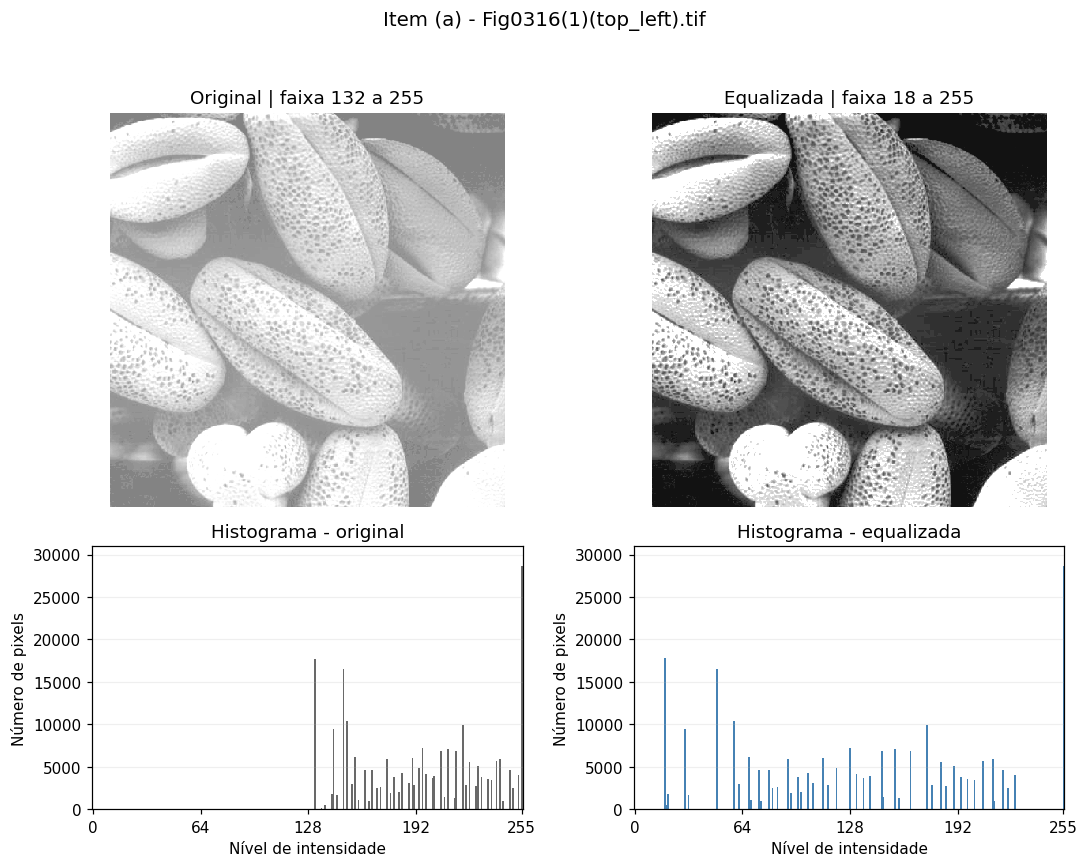

In [6]:
mostrar_comparacao("a")

**Análise.** A original concentra seus níveis na parte clara da escala: de **132 a 255**,
com média **196,35**. A equalização redistribui os níveis para **18 a 255** e
reduz a média para **132,45**. As regiões escuras passam a se diferenciar
melhor das claras. O desvio padrão aumenta de **40,26 para 74,42**.
As regiões já saturadas em branco não recuperam detalhes perdidos.

## Item (b) - Imagem de baixo contraste

Arquivo: `Fig0316(2)(2nd_from_top).tif`.

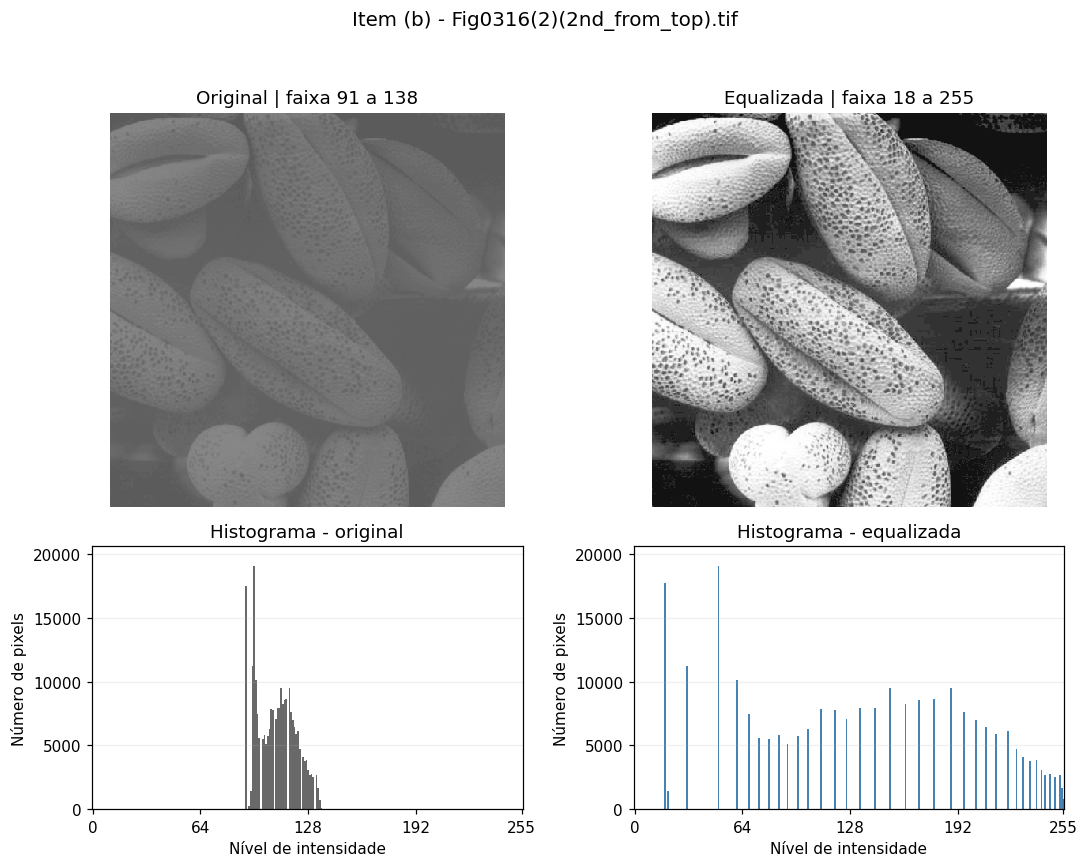

In [7]:
mostrar_comparacao("b")

**Análise.** A faixa original é estreita: **91 a 138**. Por isso, a imagem tem aparência
acinzentada e pouca separação entre suas regiões. Após a equalização, a faixa
passa a **18 a 255**, e o desvio padrão aumenta de **11,49 para 72,04**.
As texturas e os contornos ficam mais visíveis. Ainda há intervalos vazios
no histograma, pois a entrada possui apenas 42 níveis ocupados e não é
possível separar pixels originalmente iguais em novos tons diferentes.

## Item (c) - Imagem que já ocupa a faixa completa

Arquivo: `Fig0316(3)(third_from_top).tif`.

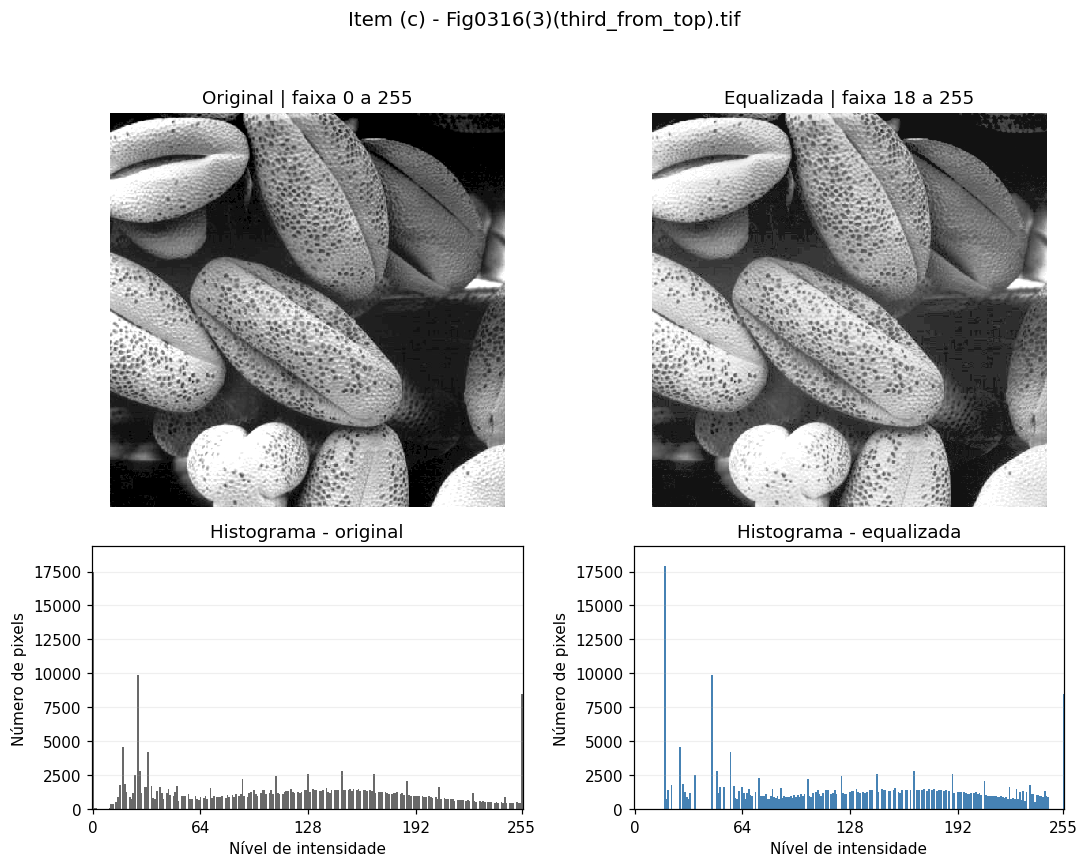

In [8]:
mostrar_comparacao("c")

**Análise.** A original já contém valores de **0 a 255**, com desvio padrão **74,56**.
A equalização ainda altera a imagem porque considera as frequências de todos
os níveis, e não apenas o mínimo e o máximo. A média aumenta de **113,16
para 129,09**, enquanto o desvio padrão diminui para **72,53**.

Nesse caso, a imagem já tinha contraste global elevado. A transformação
redistribui os tons, mas não representa um aumento desse indicador de
contraste. Isso também mostra que ocupar toda a faixa não é suficiente
para que a equalização seja a identidade.

## Item (d) - Imagem escura

Arquivo: `Fig0316(4)(bottom_left).tif`.

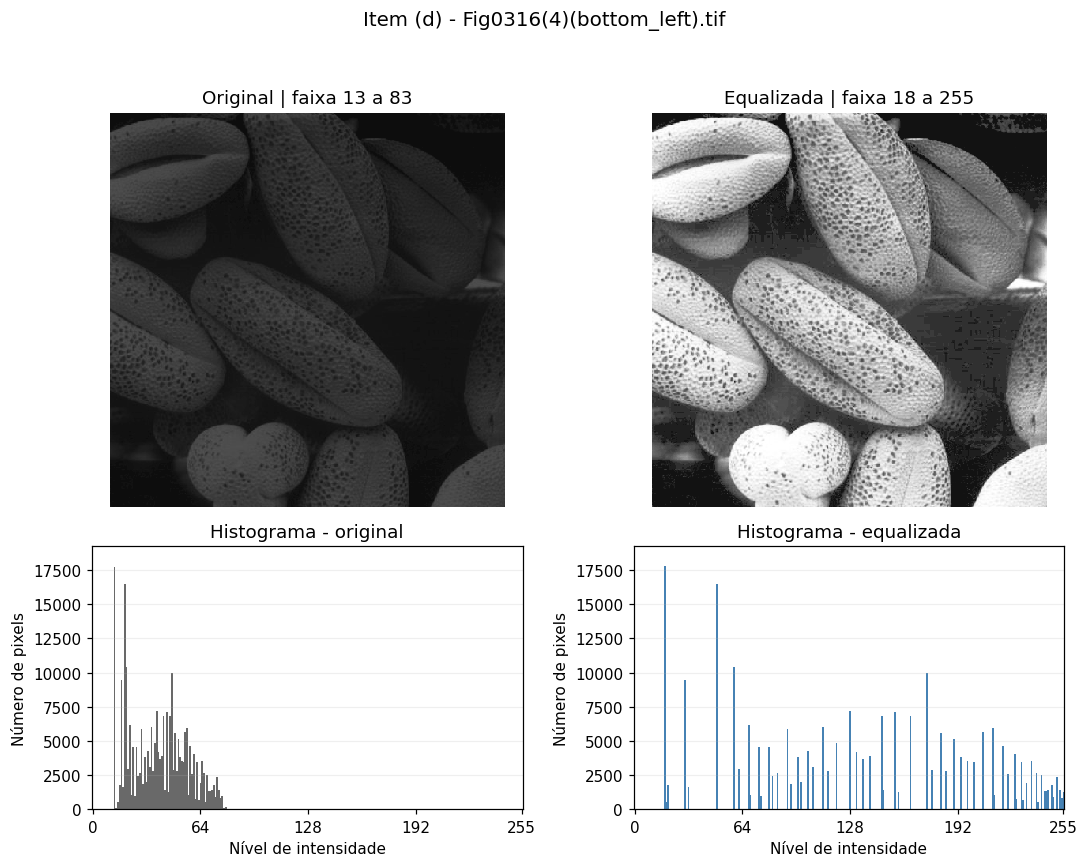

In [9]:
mostrar_comparacao("d")

**Análise.** A original concentra seus níveis na região escura: **13 a 83**, com média
**38,75**. A equalização leva a média para **130,90** e a faixa para **18 a
255**, tornando mais visíveis os detalhes que estavam comprimidos nos tons
escuros. O desvio padrão cresce de **17,26 para 72,00**.

## 4. Resumo numérico e função de transformação

A média descreve o brilho médio. O desvio padrão descreve a dispersão global
das intensidades e ajuda a comparar o contraste destas imagens, mas não mede
sozinho a qualidade visual ou a preservação de detalhes.

O número de níveis ocupados corresponde à quantidade de intensidades distintas
com frequência diferente de zero. Ele pode diminuir após o arredondamento.

In [10]:
resumo = []
for item, resultado in resultados.items():
    for etapa in ("original", "equalizada"):
        imagem = resultado[etapa]
        resumo.append({
            "item": item, "etapa": etapa,
            "pixels": int(imagem.size),
            "minimo": int(imagem.min()), "maximo": int(imagem.max()),
            "media": float(imagem.mean()), "desvio_padrao": float(imagem.std()),
            "niveis_ocupados": int(np.unique(imagem).size),
        })

with (SAIDA / "resumo_estatistico.csv").open("w", encoding="utf-8", newline="") as arquivo:
    escritor = csv.DictWriter(arquivo, fieldnames=list(resumo[0]))
    escritor.writeheader()
    escritor.writerows(resumo)

tabela = [
    "| Item | Etapa | Mínimo | Máximo | Média | Desvio padrão | Níveis ocupados |",
    "|:---:|---|---:|---:|---:|---:|---:|",
]
for linha in resumo:
    tabela.append(
        f"| {linha['item']} | {linha['etapa']} | {linha['minimo']} | "
        f"{linha['maximo']} | {linha['media']:.2f} | {linha['desvio_padrao']:.2f} | "
        f"{linha['niveis_ocupados']} |"
    )
display(Markdown("\n".join(tabela)))

| Item | Etapa | Mínimo | Máximo | Média | Desvio padrão | Níveis ocupados |
|:---:|---|---:|---:|---:|---:|---:|
| a | original | 132 | 255 | 196.35 | 40.26 | 49 |
| a | equalizada | 18 | 255 | 132.45 | 74.42 | 48 |
| b | original | 91 | 138 | 109.08 | 11.49 | 42 |
| b | equalizada | 18 | 255 | 131.92 | 72.04 | 38 |
| c | original | 0 | 255 | 113.16 | 74.56 | 198 |
| c | equalizada | 18 | 255 | 129.09 | 72.53 | 171 |
| d | original | 13 | 83 | 38.75 | 17.26 | 70 |
| d | equalizada | 18 | 255 | 130.90 | 72.00 | 64 |

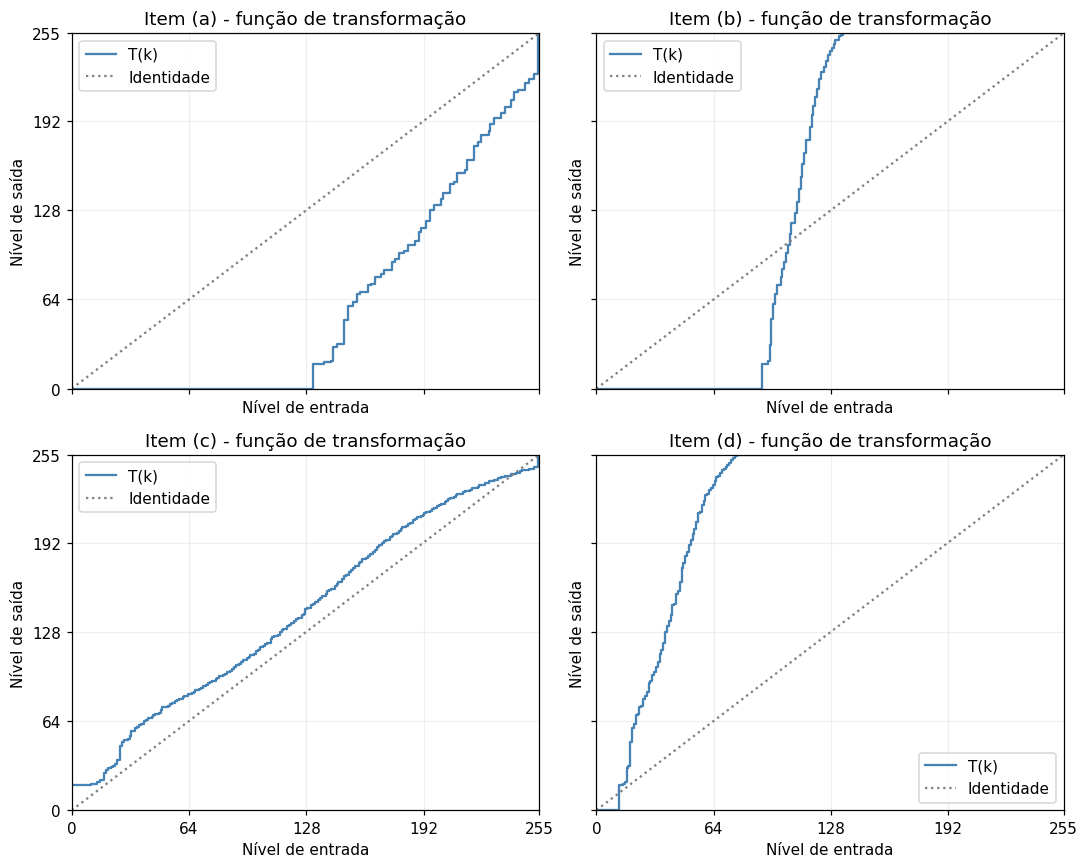

Mapeamento do menor nível presente em cada entrada:
(a) 132 -> 18 (CDF = 0.070872)
(b) 91 -> 18 (CDF = 0.069984)
(c) 0 -> 18 (CDF = 0.069984)
(d) 13 -> 18 (CDF = 0.070872)


In [11]:
fig, eixos = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
niveis = np.arange(256)
for ax, (item, resultado) in zip(eixos.ravel(), resultados.items()):
    ax.step(niveis, resultado["mapa"], where="mid", color="steelblue", label="T(k)")
    ax.plot(niveis, niveis, ":", color="gray", label="Identidade")
    ax.set_title(f"Item ({item}) - função de transformação")
    ax.set_xlabel("Nível de entrada")
    ax.set_ylabel("Nível de saída")
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 255)
    ax.set_xticks([0, 64, 128, 192, 255])
    ax.set_yticks([0, 64, 128, 192, 255])
    ax.grid(alpha=0.2)
    ax.legend()
fig.tight_layout()
fig.savefig(SAIDA / "funcoes_transformacao.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Mapeamento do menor nível presente em cada entrada:")
for item, resultado in resultados.items():
    minimo = int(resultado["original"].min())
    print(f"({item}) {minimo} -> {resultado['mapa'][minimo]} "
          f"(CDF = {resultado['cdf'][minimo]:.6f})")

## 5. Conclusões

As quatro imagens foram equalizadas de forma independente, seguindo a fórmula
do material e preservando suas dimensões de 500 × 500 pixels.

- Nos itens **(a), (b) e (d)**, a redistribuição torna mais visíveis diferenças
  que estavam concentradas em parte da escala. A imagem clara escurece, a escura
  clareia, e a de baixo contraste passa a apresentar maior separação tonal.
- No item **(c)**, a distribuição já era ampla. A equalização muda o brilho e a
  distribuição dos tons, mas o desvio padrão diminui ligeiramente. Portanto, a
  técnica não garante aumento de contraste global em qualquer imagem.
- Os histogramas de saída possuem lacunas e picos. A equalização discreta não
  distribui os pixels exatamente por igual entre os 256 níveis.
- Nas quatro saídas, o menor nível ocupado é **18**. Isso ocorre porque a CDF
  no menor nível de entrada é aproximadamente 0,07, e $255\times0{,}07$
  arredonda para 18. O método do PDF não obriga esse valor a ser zero.
- O número de tons distintos não aumenta: cai de **49 para 48**, **42 para 38**,
  **198 para 171** e **70 para 64**, respectivamente. Alguns níveis são reunidos
  pelo arredondamento. A operação realça diferenças existentes, mas não recupera
  detalhes que a imagem de entrada já havia perdido.

**Verificações:** o exemplo de 3 bits reproduziu o mapeamento e as contagens do
PDF; os histogramas das quatro imagens conservaram 250.000 pixels; os TIFFs
gravados e os histogramas relidos dos CSVs coincidiram com os dados calculados.

## Referência

Material disponibilizado na disciplina: **Histograma_Equalizacao.pdf**,
professor André Alessandro Stein, IFC - Campus Rio do Sul, páginas 1 a 3.
A cópia recebida tem cabeçalho de 23/11/2021. Foram utilizadas a equação 3.3-8,
o exemplo de 3 bits e as quatro imagens indicadas na atividade.